<a href="https://colab.research.google.com/github/LaloVargas1310/Limpieza-Datos-Cancer/blob/main/Actividad_lll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Cargar el dataset original
df = pd.read_csv("Breast_Cancer.csv")

print("--- 1. ESTADO ORIGINAL ---")
print(f"Total de registros originales: {df.shape[0]} filas y {df.shape[1]} columnas.")

# --- PASO A: Renombrar y estandarizar columnas ---
# Quitamos espacios y corregimos el error tipográfico "Reginol" del dataset original
df.rename(columns={
    'Marital Status': 'Marital_Status',
    'T Stage ': 'T_Stage',
    'N Stage': 'N_Stage',
    '6th Stage': '6th_Stage',
    'Tumor Size': 'Tumor_Size',
    'Estrogen Status': 'Estrogen_Status',
    'Progesterone Status': 'Progesterone_Status',
    'Regional Node Examined': 'Regional_Node_Examined',
    'Reginol Node Positive': 'Regional_Node_Positive', # Error corregido
    'Survival Months': 'Survival_Months'
}, inplace=True)
df.columns = df.columns.str.strip() # Limpia espacios accidentales al inicio/final

# --- PASO B: Búsqueda de Valores Nulos (Missing Values) ---
print("\n--- 2. VALORES NULOS ---")
nulos = df.isnull().sum().sum()
print(f"Total de valores nulos o vacíos encontrados: {nulos}")

# --- PASO C: Identificación y eliminación de Duplicados ---
print("\n--- 3. DATOS DUPLICADOS ---")
duplicados = df.duplicated().sum()
print(f"Filas exactamente duplicadas encontradas: {duplicados}")
# Eliminamos los duplicados manteniendo solo la primera aparición
df = df.drop_duplicates()
print(f"Registros después de eliminar duplicados: {df.shape[0]}")

# --- PASO D: Tratamiento de Valores Atípicos (Outliers) ---
# En la Actividad 3 vimos que había tumores gigantes. Calculamos el límite con el método IQR.
Q1 = df['Tumor_Size'].quantile(0.25)
Q3 = df['Tumor_Size'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print("\n--- 4. VALORES ATÍPICOS ---")
outliers_tumor = df[df['Tumor_Size'] > limite_superior]
print(f"Pacientes con tumores atípicamente grandes (> {limite_superior} mm): {outliers_tumor.shape[0]}")
# Nota médica: No los borramos porque un tumor de 100mm es un dato médico real y valioso para el modelo, pero sí los identificamos.

print("\n--- 5. ESTADO FINAL ---")
print(f"Total de registros listos: {df.shape[0]} filas y {df.shape[1]} columnas.")

# Guardar el dataset ya limpio para usarlo en las siguientes tareas
df.to_csv("Breast_Cancer_Limpio.csv", index=False)
print("\n¡Dataset limpio guardado como 'Breast_Cancer_Limpio.csv'!")

--- 1. ESTADO ORIGINAL ---
Total de registros originales: 4024 filas y 16 columnas.

--- 2. VALORES NULOS ---
Total de valores nulos o vacíos encontrados: 0

--- 3. DATOS DUPLICADOS ---
Filas exactamente duplicadas encontradas: 1
Registros después de eliminar duplicados: 4023

--- 4. VALORES ATÍPICOS ---
Pacientes con tumores atípicamente grandes (> 71.0 mm): 222

--- 5. ESTADO FINAL ---
Total de registros listos: 4023 filas y 16 columnas.

¡Dataset limpio guardado como 'Breast_Cancer_Limpio.csv'!


--- VISTA PREVIA DE LOS DATOS LIMPIOS ---


,Age,Race,Marital_Status,T_Stage,N_Stage,6th_Stage,differentiate,Grade,A Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


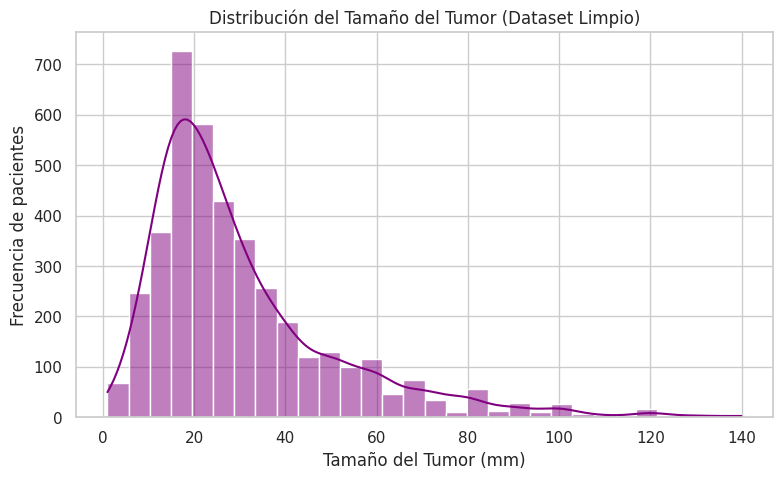

/tmp/ipykernel_6266/2109479011.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Survival_Months', data=df_limpio, palette='Set2')


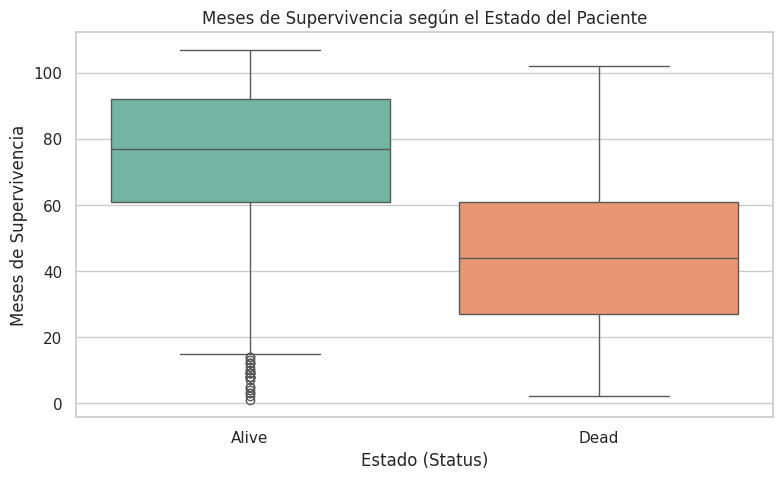

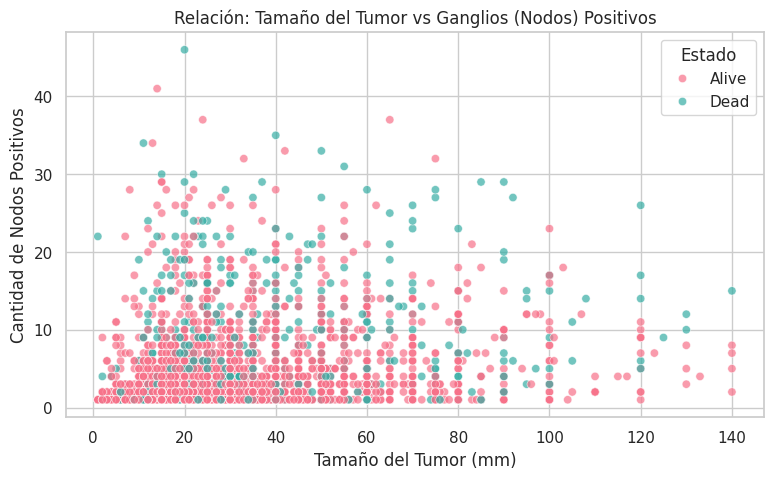

/tmp/ipykernel_6266/2109479011.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Estrogen_Status', data=df_limpio, palette='pastel')


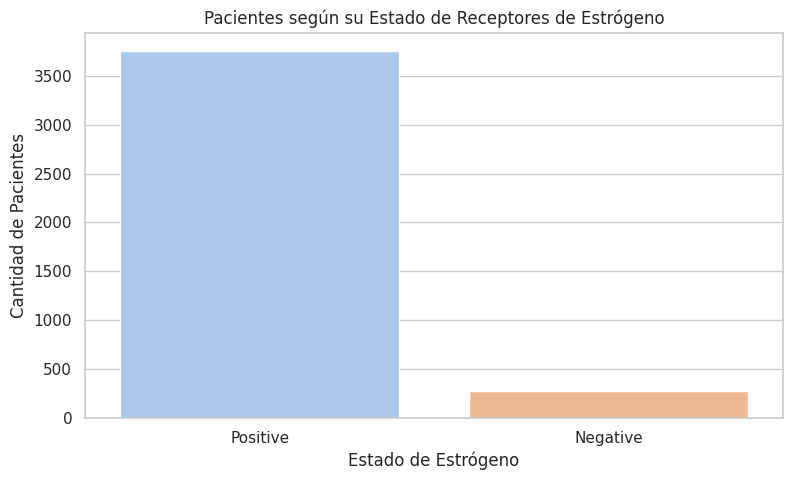

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset LIMPIO
df_limpio = pd.read_csv("Breast_Cancer_Limpio.csv")

# Mostrar las primeras 5 filas para confirmar que cargó bien
print("--- VISTA PREVIA DE LOS DATOS LIMPIOS ---")
display(df_limpio.head())

# Configurar el estilo de las gráficas
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICA 1: Histograma del Tamaño del Tumor
# ==========================================
plt.figure(figsize=(9, 5))
sns.histplot(df_limpio['Tumor_Size'], bins=30, kde=True, color='purple')
plt.title('Distribución del Tamaño del Tumor (Dataset Limpio)')
plt.xlabel('Tamaño del Tumor (mm)')
plt.ylabel('Frecuencia de pacientes')
plt.show()

# ==========================================
# GRÁFICA 2: Boxplot (Supervivencia vs Estado)
# ==========================================
plt.figure(figsize=(9, 5))
sns.boxplot(x='Status', y='Survival_Months', data=df_limpio, palette='Set2')
plt.title('Meses de Supervivencia según el Estado del Paciente')
plt.xlabel('Estado (Status)')
plt.ylabel('Meses de Supervivencia')
plt.show()

# ==========================================
# GRÁFICA 3: Dispersión (Nodos Positivos vs Tamaño del Tumor)
# ==========================================
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Tumor_Size', y='Regional_Node_Positive', hue='Status', data=df_limpio, alpha=0.7, palette='husl')
plt.title('Relación: Tamaño del Tumor vs Ganglios (Nodos) Positivos')
plt.xlabel('Tamaño del Tumor (mm)')
plt.ylabel('Cantidad de Nodos Positivos')
plt.legend(title='Estado')
plt.show()

# ==========================================
# GRÁFICA 4: Gráfico de Barras (Estado de Estrógeno)
# ==========================================
plt.figure(figsize=(9, 5))
sns.countplot(x='Estrogen_Status', data=df_limpio, palette='pastel')
plt.title('Pacientes según su Estado de Receptores de Estrógeno')
plt.xlabel('Estado de Estrógeno')
plt.ylabel('Cantidad de Pacientes')
plt.show()